# FNO Battery Surrogate — Model Analysis

This notebook loads and tests the FNO models for lithium and sodium, evaluating them with the respective PyBaMM simulations

## 1. Setup & Configuration

In [1]:
import time

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pybamm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import DataLoader, Subset

# Model, dataset and dataloader logic are imported from the training script (training_loop.py)
from training_loop import BatteryDataset, FNO2d, get_dataloaders

In [2]:
DEVICE = torch.device("cpu")  # Inference / analysis is fast enough on CPU

MODEL_KWARGS = dict(modes1=16, modes2=16, width=32) # split info taken from training_loop.py, same as the model used for training

CHEMISTRIES = {
    "lithium": {
        "label": "Lithium (Li-ion)",
        "model_path": "fno_lithium_model.pth",
        "dataset_file": "dataset_lithium_normalized.npz",
        "pybamm_parameter_set": "Chen2020",
    },
    "sodium": {
        "label": "Sodium (Na-ion)",
        "model_path": "fno_sodium_model.pth",
        "dataset_file": "dataset_sodium_normalized.npz",
        "pybamm_parameter_set": "Chayambuka2022",
    },
}

# Macro-geometry parameters from the Chen2020 (lithium) to apply onto the sodium cell
# Kept here so the benchmark section can rebuild the exact same PyBaMM setup.
MACRO_GEOMETRY_PARAMETERS = [
    "Nominal cell capacity [A.h]",
    "Electrode height [m]",
    "Electrode width [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Positive electrode thickness [m]",
    "Number of electrodes connected in parallel to make a cell",
    "Cell volume [m3]",
    "Cell cooling surface area [m2]",
]


VAR_PTS = {"x_n": 21, "x_s": 20, "x_p": 21, "r_n": 10, "r_p": 10}

# The two chemistries now expose DIFFERENT PyBaMM input parameter names:
# - lithium: anode/cathode diffusivity stay absolute constants (Chen2020's own defaults are plain scalars); only the electrolyte is scale-factored on top of the Nyman2008 curve.
# - sodium: all three diffusivities are scale factors on Chayambuka2022's literature curves (HC_diffusivity / NVPF_diffusivity / electrolyte_diffusivity), since those curves are strongly state-of-charge / concentration dependent.
# Must be kept in sync with Dataset_Generator_Li.py / Dataset_Generator_Na.py.
INPUT_NAMES = {
    "lithium": [
        "Current function [A]",
        "Negative electrode diffusivity [m2.s-1]",
        "Positive electrode diffusivity [m2.s-1]",
        "Electrolyte diffusivity scale factor",
    ],
    "sodium": [
        "Current function [A]",
        "Anode diffusivity scale factor",
        "Cathode diffusivity scale factor",
        "Electrolyte diffusivity scale factor",
    ],
}

# Column 1-2 display labels differ by chemistry (absolute value vs. scale factor)
# Used by the plotting/labeling code below instead of hardcoding "$D_a$"/"$D_c$" everywhere
PARAM_LABELS = {
    "lithium": ["Current", "D_anode (log)", "D_cathode (log)", "k_electrolyte (log)"],
    "sodium": ["Current", "k_anode (log)", "k_cathode (log)", "k_electrolyte (log)"],
}

# Sodium's current range has a documented, empirically-confirmed solver-survival ceiling
# (~4.1-4.2 A, consistent across two independent generation runs at different pool sizes)
NA_MAX_TRAINED_CURRENT_A = 4.16  # hard boundary: should never exceed when querying the sodium model

# For head-to-head Na-vs-Li accuracy comparisons: restrict to samples below this current so both chemistries have comparable k_electrolyte coverage
# (below ~2.5A sodium's LHS sampling is not yet skewed by the solver-survival bias at higher currents)
FAIR_COMPARISON_CURRENT_THRESHOLD_A = 2.5

## 2. Helper Functions

In [3]:
def denormalize(tensor, min_val, max_val):
    """Reverts the [-1, 1] normalization back to the original physical scale."""
    return ((tensor + 1.0) / 2.0) * (max_val - min_val) + min_val


def get_geometry(parameter_set="Chen2020"):
    """
    Physical electrode/separator thicknesses [um] and layer boundaries.
    Both chemistries share the same macro-geometry by design (iso-geometric comparison), 
    so Chen2020 alone is enough to describe either cell's layout.
    """
    params = pybamm.ParameterValues(parameter_set)
    L_n = params["Negative electrode thickness [m]"] * 1e6
    L_s = params["Separator thickness [m]"] * 1e6
    L_p = params["Positive electrode thickness [m]"] * 1e6
    return {
        "L_n": L_n,
        "L_s": L_s,
        "L_p": L_p,
        "L_total": L_n + L_s + L_p,
        "sep_start": L_n,
        "cat_start": L_n + L_s,
    }


def load_trained_model(model_path, model_cls=FNO2d, device=DEVICE):
    """Loads a trained FNO checkpoint (any FNO2d subclass) into eval mode."""
    model = model_cls(**MODEL_KWARGS).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def get_test_split(full_dataset, npz_path):
    """Returns the held-out test split saved by Dataset_Normalizer.py
    (train_idx/val_idx/test_idx), matching training_loop.py's get_dataloaders()"""
    raw = np.load(npz_path)
    return Subset(full_dataset, raw["test_idx"])


def build_pybamm_simulation(chemistry_key, var_pts=None):
    """
    Builds the PyBaMM simulation matching how each chemistry's dataset was generated.
    Mirrors Dataset_Generator_Li.py / Dataset_Generator_Na.py exactly -- both chemistries
    scale-factor their electrolyte diffusivity on top of the literature curve (Nyman2008 for
    lithium, Chayambuka2022 for sodium); sodium additionally scale-factors anode and cathode
    (Chayambuka2022's curves are strongly state-of-charge dependent, unlike Chen2020's plain
    scalar defaults for lithium's anode/cathode -- verified directly, see Testing Area).
    Pass a custom `var_pts` (e.g. a finer mesh) to override the default training-time mesh.
    """
    if var_pts is None:
        var_pts = VAR_PTS

    if chemistry_key == "lithium":
        param = pybamm.ParameterValues("Chen2020")
        param["Lower voltage cut-off [V]"] = 2.5

        base_D_electrolyte = param["Electrolyte diffusivity [m2.s-1]"]

        def scaled_D_electrolyte(c_e, T):
            return pybamm.InputParameter("Electrolyte diffusivity scale factor") * base_D_electrolyte(c_e, T)

        param["Current function [A]"] = "[input]"
        param["Negative electrode diffusivity [m2.s-1]"] = "[input]"  # absolute, unchanged
        param["Positive electrode diffusivity [m2.s-1]"] = "[input]"  # absolute, unchanged
        param["Electrolyte diffusivity [m2.s-1]"] = scaled_D_electrolyte
        model_pb = pybamm.lithium_ion.DFN()

    elif chemistry_key == "sodium":
        param_li = pybamm.ParameterValues("Chen2020")
        param = pybamm.ParameterValues("Chayambuka2022")
        param["Lower voltage cut-off [V]"] = 2
        for p in MACRO_GEOMETRY_PARAMETERS:
            param[p] = param_li[p]

        base_D_anode = param["Negative electrode diffusivity [m2.s-1]"]
        base_D_cathode = param["Positive electrode diffusivity [m2.s-1]"]
        base_D_electrolyte = param["Electrolyte diffusivity [m2.s-1]"]

        def scaled_D_anode(sto, T):
            return pybamm.InputParameter("Anode diffusivity scale factor") * base_D_anode(sto, T)

        def scaled_D_cathode(sto, T):
            return pybamm.InputParameter("Cathode diffusivity scale factor") * base_D_cathode(sto, T)

        def scaled_D_electrolyte(c_e, T):
            return pybamm.InputParameter("Electrolyte diffusivity scale factor") * base_D_electrolyte(c_e, T)

        param["Current function [A]"] = "[input]"
        param["Negative electrode diffusivity [m2.s-1]"] = scaled_D_anode
        param["Positive electrode diffusivity [m2.s-1]"] = scaled_D_cathode
        param["Electrolyte diffusivity [m2.s-1]"] = scaled_D_electrolyte
        model_pb = pybamm.sodium_ion.BasicDFN()

    else:
        raise ValueError(f"Unknown chemistry: {chemistry_key}")

    return pybamm.Simulation(model_pb, parameter_values=param, var_pts=var_pts, solver=pybamm.CasadiSolver(mode="safe"))

## 3. Sanity Checks (before training in training_loop.py)

In [4]:
train_loader, val_loader, test_loader, sf = get_dataloaders(
    CHEMISTRIES["lithium"]["dataset_file"], batch_size=16
)

inputs, targets = next(iter(train_loader))
print(f"Inputs shape  (Batch x Params)                 : {inputs.shape}")
print(f"Targets shape (Batch x Channels x Space x Time) : {targets.shape}")

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Inputs shape  (Batch x Params)                 : torch.Size([16, 4])
Targets shape (Batch x Channels x Space x Time) : torch.Size([16, 1, 64, 100])


In [5]:
model = FNO2d(**MODEL_KWARGS)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {n_params:,}")

dummy_input = torch.randn(16, 4)
predictions = model(dummy_input)
print(f"Dummy input shape : {dummy_input.shape}")
print(f"Output shape       : {predictions.shape}")

assert predictions.shape == (16, 1, 64, 100), "Output dimensions do not match expectations!"
print("OK — the FNO correctly maps parameters onto a (space x time) grid.")

Total trainable parameters: 2,105,953
Dummy input shape : torch.Size([16, 4])
Output shape       : torch.Size([16, 1, 64, 100])
OK — the FNO correctly maps parameters onto a (space x time) grid.


## 4. Qualitative Inference — FNO vs. Ground Truth

Picks a sample, runs the FNO on it, and compares it side-by-side with the PyBaMM ground truth

In [6]:
def plot_prediction_vs_ground_truth(chemistry_key, sample_idx=None):
    cfg = CHEMISTRIES[chemistry_key]
    full_dataset = BatteryDataset(cfg["dataset_file"])
    sf = full_dataset.scaling_factors
    I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, Y_min, Y_max = sf

    if sample_idx is None:
        # Default to a sample drawn from the held-out test region (last ~10%)
        sample_idx = int(0.9 * len(full_dataset)) + 10

    inputs_norm, targets_norm = full_dataset[sample_idx]
    inputs_norm = inputs_norm.unsqueeze(0)
    targets_norm = targets_norm.unsqueeze(0)

    model = load_trained_model(cfg["model_path"])
    with torch.no_grad():
        predictions_norm = model(inputs_norm)

    inputs_phys = inputs_norm.squeeze().numpy()
    I_phys = denormalize(inputs_phys[0], I_min, I_max)
    Da_phys = 10 ** denormalize(inputs_phys[1], Da_min, Da_max)
    Dc_phys = 10 ** denormalize(inputs_phys[2], Dc_min, Dc_max)
    De_phys = 10 ** denormalize(inputs_phys[3], De_min, De_max)

    target_phys = denormalize(targets_norm.squeeze().numpy(), Y_min, Y_max)
    pred_phys = denormalize(predictions_norm.squeeze().numpy(), Y_min, Y_max)

    geom = get_geometry()

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    vmin = min(np.min(target_phys), np.min(pred_phys))
    vmax = max(np.max(target_phys), np.max(pred_phys))

    im1 = axes[0].imshow(target_phys, aspect="auto", origin="lower", cmap="viridis",
                          extent=[0, 100, 0, geom["L_total"]], vmin=vmin, vmax=vmax)
    axes[0].set_title("Ground Truth (PyBaMM Solver)", fontweight="bold", fontsize=14)
    axes[0].set_ylabel(r"Physical Depth [$\mu m$]", fontsize=12, fontweight="bold")

    im2 = axes[1].imshow(pred_phys, aspect="auto", origin="lower", cmap="viridis",
                          extent=[0, 100, 0, geom["L_total"]], vmin=vmin, vmax=vmax)
    axes[1].set_title("FNO Prediction (Neural Surrogate)", fontweight="bold", fontsize=14)

    error_map = np.abs(target_phys - pred_phys)
    im3 = axes[2].imshow(error_map, aspect="auto", origin="lower", cmap="magma",
                          extent=[0, 100, 0, geom["L_total"]])
    axes[2].set_title("Absolute Error (|Truth - Pred|)", fontweight="bold", fontsize=14)

    for i, ax in enumerate(axes):
        ax.axhline(y=geom["sep_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.axhline(y=geom["cat_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.set_xlabel("Normalized Time (% until cut-off)", fontsize=12)
        ax.grid(False)
        if i > 0:
            ax.set_yticklabels([])

    labels = ["Electrolyte Concentration [mol/m\u00b3]",
              "Electrolyte Concentration [mol/m\u00b3]",
              "Error [mol/m\u00b3]"]
    for ax, im, label in zip(axes, [im1, im2, im3], labels):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im, cax=cax, label=label)

    if chemistry_key == "lithium":
        param_str = f"I = {I_phys:.2f} A | $D_a$={Da_phys:.1e} | $D_c$={Dc_phys:.1e} | $k_e$={De_phys:.2f}x"
    else:
        param_str = f"I = {I_phys:.2f} A | $k_a$={Da_phys:.2f}x | $k_c$={Dc_phys:.2f}x | $k_e$={De_phys:.2f}x"

    plt.suptitle(
        f"AI vs Physics Engine Validation — {cfg['label']} (sample #{sample_idx})\n" + param_str,
        fontsize=16, fontweight="bold", y=1.05
    )
    plt.tight_layout()
    plt.show()

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])


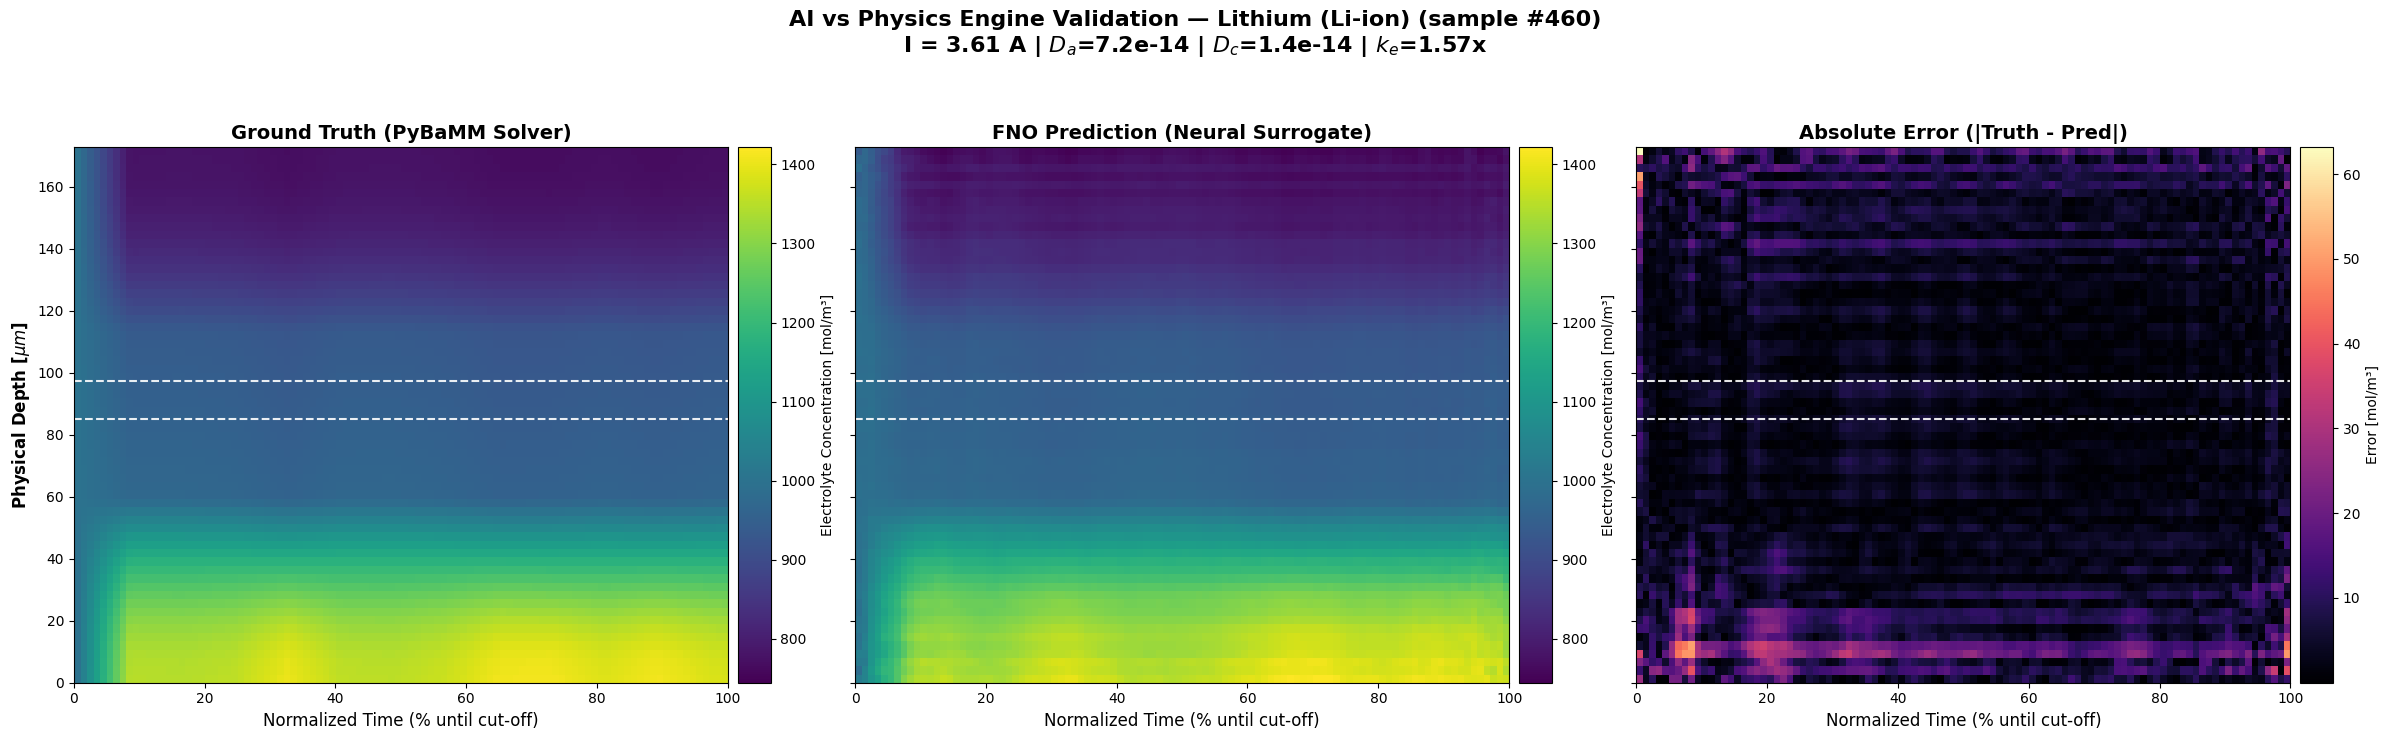

Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])


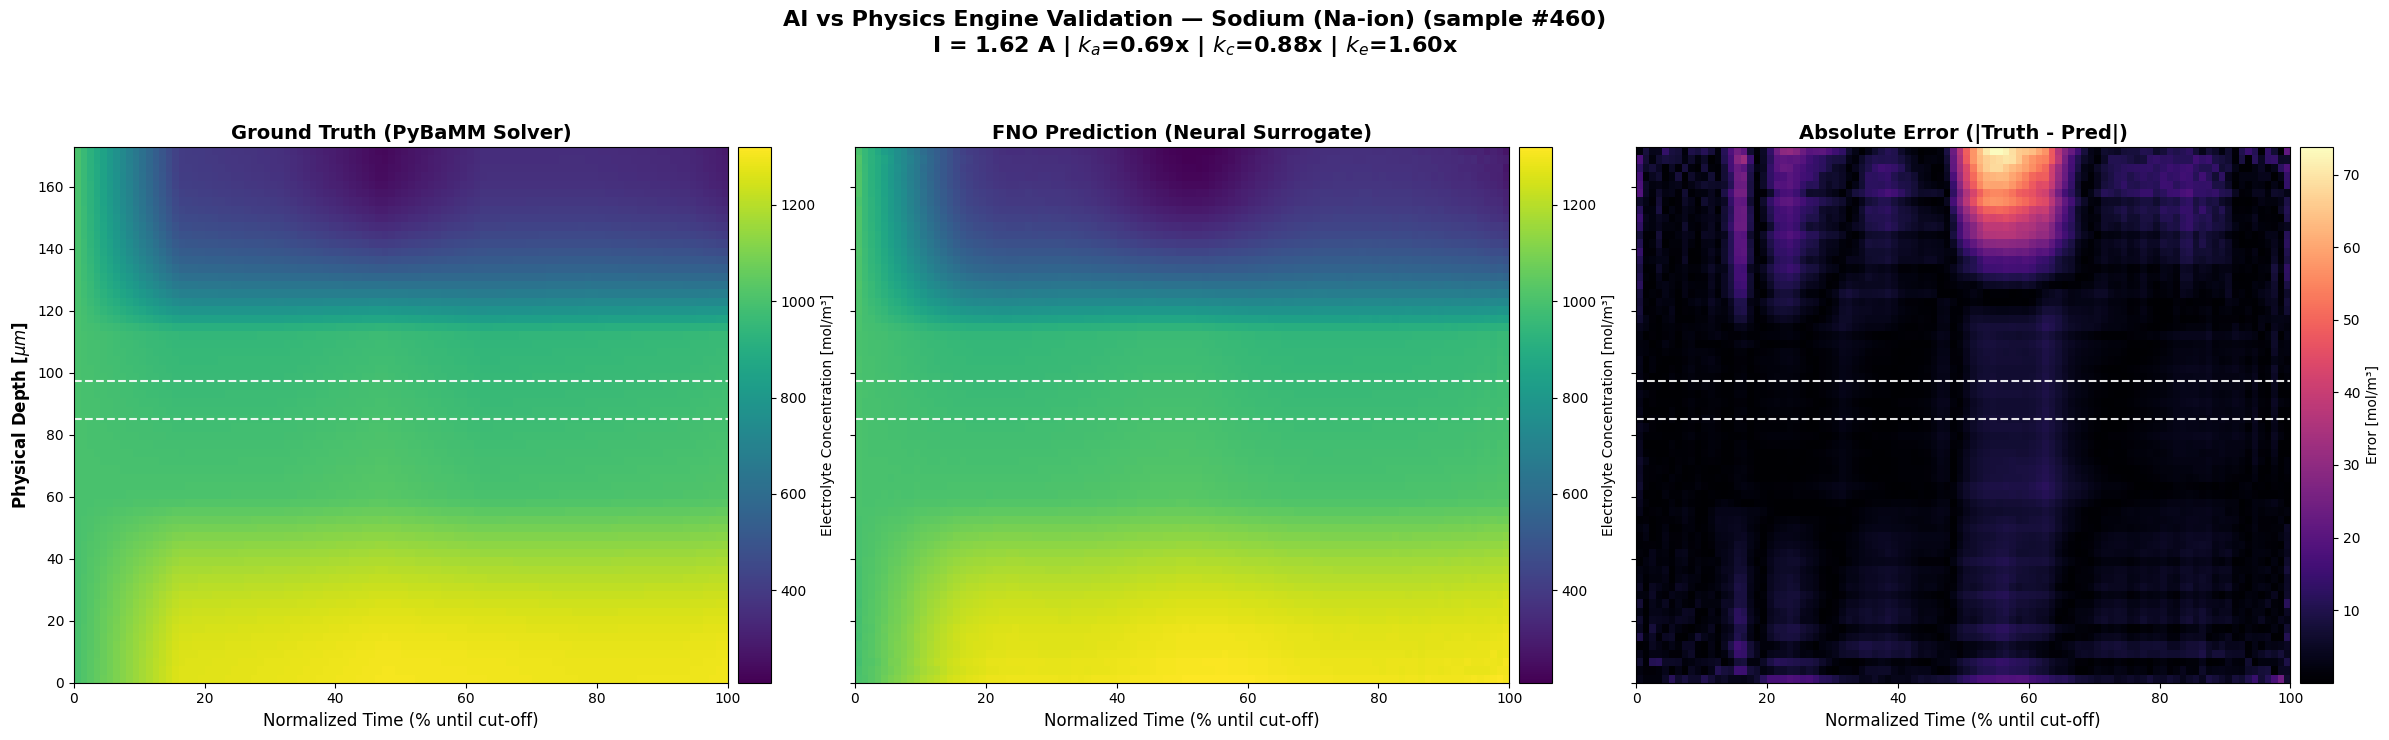

In [7]:
plot_prediction_vs_ground_truth("lithium")
plot_prediction_vs_ground_truth("sodium")

## 5. Quantitative Evaluation — Test-Set Metrics

RMSE, MAE and relative error over the entire test split, for both chemistries

In [4]:
def evaluate_test_set(chemistry_key):
    cfg = CHEMISTRIES[chemistry_key]
    full_dataset = BatteryDataset(cfg["dataset_file"])
    sf = full_dataset.scaling_factors
    Y_min, Y_max = sf[8], sf[9]

    test_dataset = get_test_split(full_dataset, cfg["dataset_file"])
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    model = load_trained_model(cfg["model_path"])

    all_rmse, all_mae, all_relative_errors = [], [], []
    worst_rmse, worst_idx = 0.0, -1
    best_rmse, best_idx = float("inf"), -1

    with torch.no_grad():
        for i, (inputs_norm, targets_norm) in enumerate(test_loader):
            predictions_norm = model(inputs_norm.to(DEVICE))

            target_phys = denormalize(targets_norm.squeeze().numpy(), Y_min, Y_max)
            pred_phys = denormalize(predictions_norm.squeeze().numpy(), Y_min, Y_max)

            rmse = np.sqrt(np.mean((target_phys - pred_phys) ** 2))
            mae = np.mean(np.abs(target_phys - pred_phys))
            rel_error = (mae / np.mean(target_phys)) * 100

            all_rmse.append(rmse)
            all_mae.append(mae)
            all_relative_errors.append(rel_error)

            if rmse > worst_rmse:
                worst_rmse, worst_idx = rmse, i
            if rmse < best_rmse:
                best_rmse, best_idx = rmse, i

    print("=" * 50)
    print(f"             FINAL TEST SET METRICS: {cfg['label']}")
    print("=" * 50)
    print(f"Number of Samples Evaluated : {len(test_dataset)}")
    print(f"Mean Absolute Error (MAE)   : {np.mean(all_mae):.2f} mol/m\u00b3")
    print(f"Median RMSE                 : {np.median(all_rmse):.2f} mol/m³")
    print(f"Root Mean Square Error(RMSE): {np.mean(all_rmse):.2f} \u00b1 {np.std(all_rmse):.2f} mol/m\u00b3")
    print(f"Average Relative Error      : {np.mean(all_relative_errors):.3f} %")
    print("-" * 50)
    print(f"Worst Simulation Index      : #{worst_idx} (RMSE: {worst_rmse:.2f} mol/m\u00b3)")
    print(f"Best Simulation Index       : #{best_idx} (RMSE: {best_rmse:.2f} mol/m\u00b3)")
    print("=" * 50)


    return {"rmse": all_rmse, "mae": all_mae, "rel_error": all_relative_errors,
            "worst_idx": worst_idx, "best_idx": best_idx}

In [5]:
eval_results = {}
for chemistry_key in CHEMISTRIES:
    eval_results[chemistry_key] = evaluate_test_set(chemistry_key)
    print()

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
             FINAL TEST SET METRICS: Lithium (Li-ion)
Number of Samples Evaluated : 50
Mean Absolute Error (MAE)   : 15.44 mol/m³
Median RMSE                 : 18.06 mol/m³
Root Mean Square Error(RMSE): 22.15 ± 20.72 mol/m³
Average Relative Error      : 1.590 %
--------------------------------------------------
Worst Simulation Index      : #46 (RMSE: 131.38 mol/m³)
Best Simulation Index       : #48 (RMSE: 5.58 mol/m³)

Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
             FINAL TEST SET METRICS: Sodium (Na-ion)
Number of Samples Evaluated : 50
Mean Absolute Error (MAE)   : 5.69 mol/m³
Median RMSE                 : 8.68 mol/m³
Root Mean Square Error(RMSE): 9.98 ± 5.50 mol/m³
Average Relative Error      : 0.630 %
--------------------------------------------------
Worst S

##### 5.1. Extra: plot of the best and worst predictions for each chemistry.

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size(

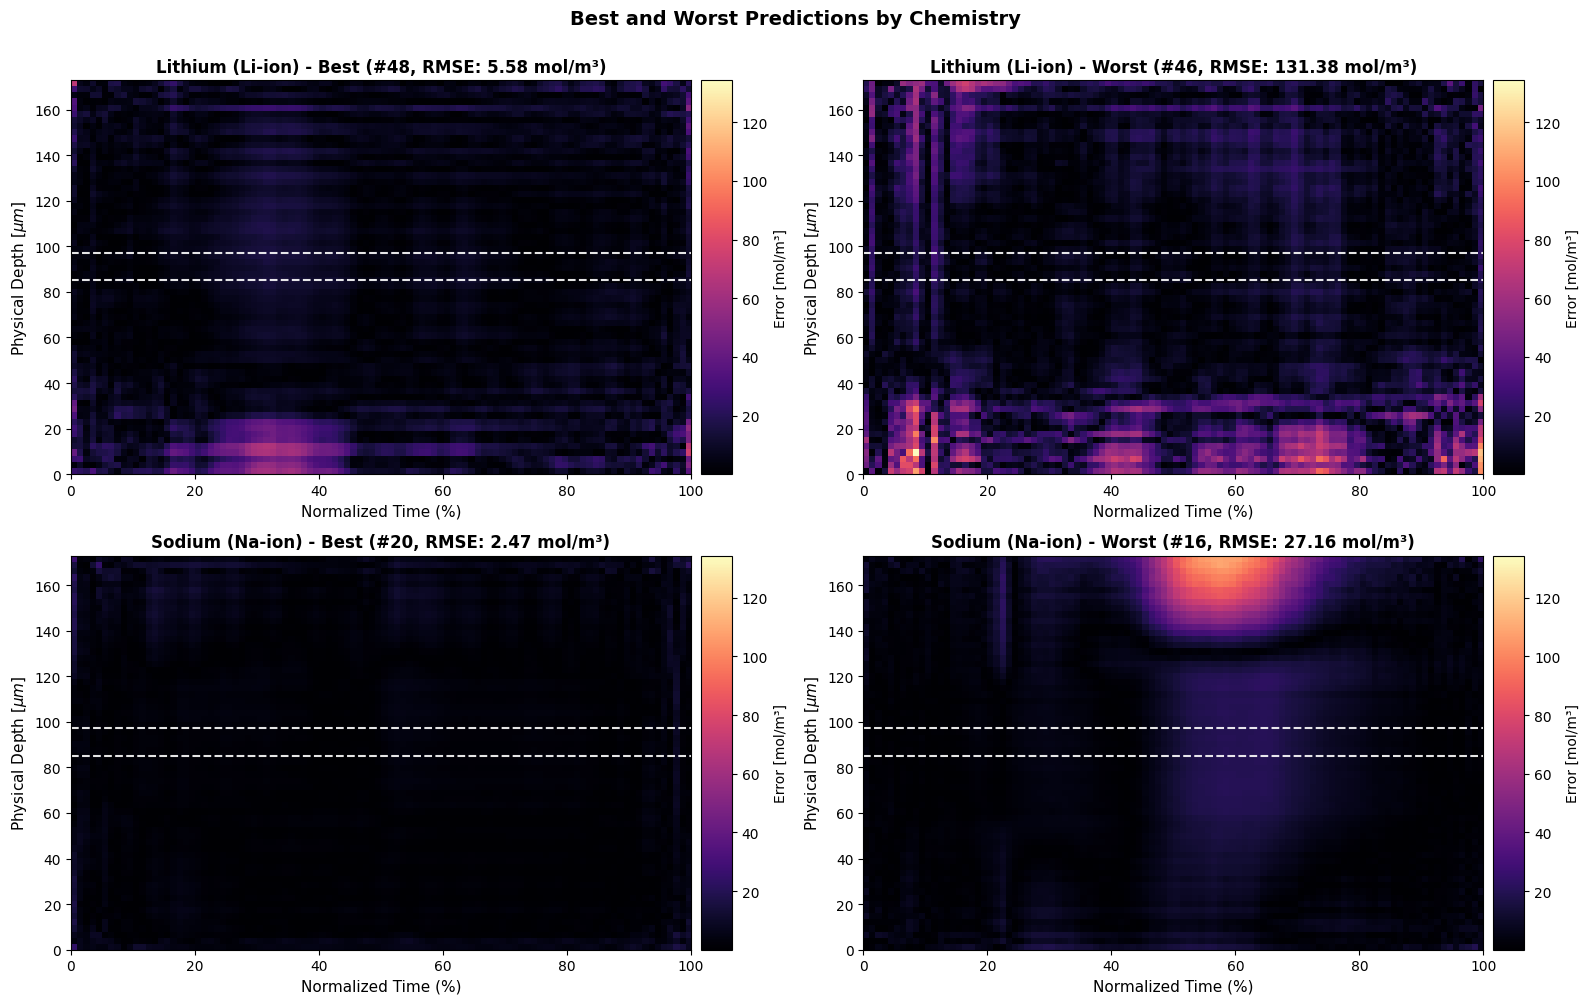

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

all_error_maps = []

for chem_idx, chemistry_key in enumerate(CHEMISTRIES.keys()):
    cfg = CHEMISTRIES[chemistry_key]
    best_idx = eval_results[chemistry_key]["best_idx"]
    worst_idx = eval_results[chemistry_key]["worst_idx"]

    for idx_type, idx in enumerate([best_idx, worst_idx]):
        full_dataset = BatteryDataset(cfg["dataset_file"])
        sf = full_dataset.scaling_factors
        I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, Y_min, Y_max = sf

        inputs_norm, targets_norm = full_dataset[idx]
        inputs_norm = inputs_norm.unsqueeze(0)
        targets_norm = targets_norm.unsqueeze(0)

        model = load_trained_model(cfg["model_path"])
        with torch.no_grad():
            predictions_norm = model(inputs_norm)

        target_phys = denormalize(targets_norm.squeeze().numpy(), Y_min, Y_max)
        pred_phys = denormalize(predictions_norm.squeeze().numpy(), Y_min, Y_max)
        error_map = np.abs(target_phys - pred_phys)
        all_error_maps.append(error_map)

common_vmin = min(np.min(err) for err in all_error_maps)
common_vmax = max(np.max(err) for err in all_error_maps)

for chem_idx, chemistry_key in enumerate(CHEMISTRIES.keys()):
    cfg = CHEMISTRIES[chemistry_key]
    best_idx = eval_results[chemistry_key]["best_idx"]
    worst_idx = eval_results[chemistry_key]["worst_idx"]

    for idx_type, idx in enumerate([best_idx, worst_idx]):
        full_dataset = BatteryDataset(cfg["dataset_file"])
        sf = full_dataset.scaling_factors
        I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, Y_min, Y_max = sf

        inputs_norm, targets_norm = full_dataset[idx]
        inputs_norm = inputs_norm.unsqueeze(0)
        targets_norm = targets_norm.unsqueeze(0)

        model = load_trained_model(cfg["model_path"])
        with torch.no_grad():
            predictions_norm = model(inputs_norm)

        target_phys = denormalize(targets_norm.squeeze().numpy(), Y_min, Y_max)
        pred_phys = denormalize(predictions_norm.squeeze().numpy(), Y_min, Y_max)
        error_map = np.abs(target_phys - pred_phys)

        geom = get_geometry()
        ax = axes[chem_idx, idx_type]
        im = ax.imshow(
            error_map,
            aspect="auto",
            origin="lower",
            cmap="magma",
            extent=[0, 100, 0, geom["L_total"]],
            vmin=common_vmin,
            vmax=common_vmax,
        )
        ax.axhline(y=geom["sep_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.axhline(y=geom["cat_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.set_xlabel("Normalized Time (%)", fontsize=11)
        ax.set_ylabel(r"Physical Depth [$\mu m$]", fontsize=11)

        label_type = "Best" if idx_type == 0 else "Worst"
        rmse = eval_results[chemistry_key]["rmse"][idx]
        ax.set_title(
            f"{cfg['label']} - {label_type} (#{idx}, RMSE: {rmse:.2f} mol/m³)",
            fontweight="bold",
            fontsize=12,
        )

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im, cax=cax, label="Error [mol/m³]")

plt.suptitle("Best and Worst Predictions by Chemistry", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### 5.5. Outlier analysis - RMSE w.r.t. the singular input parameters

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])


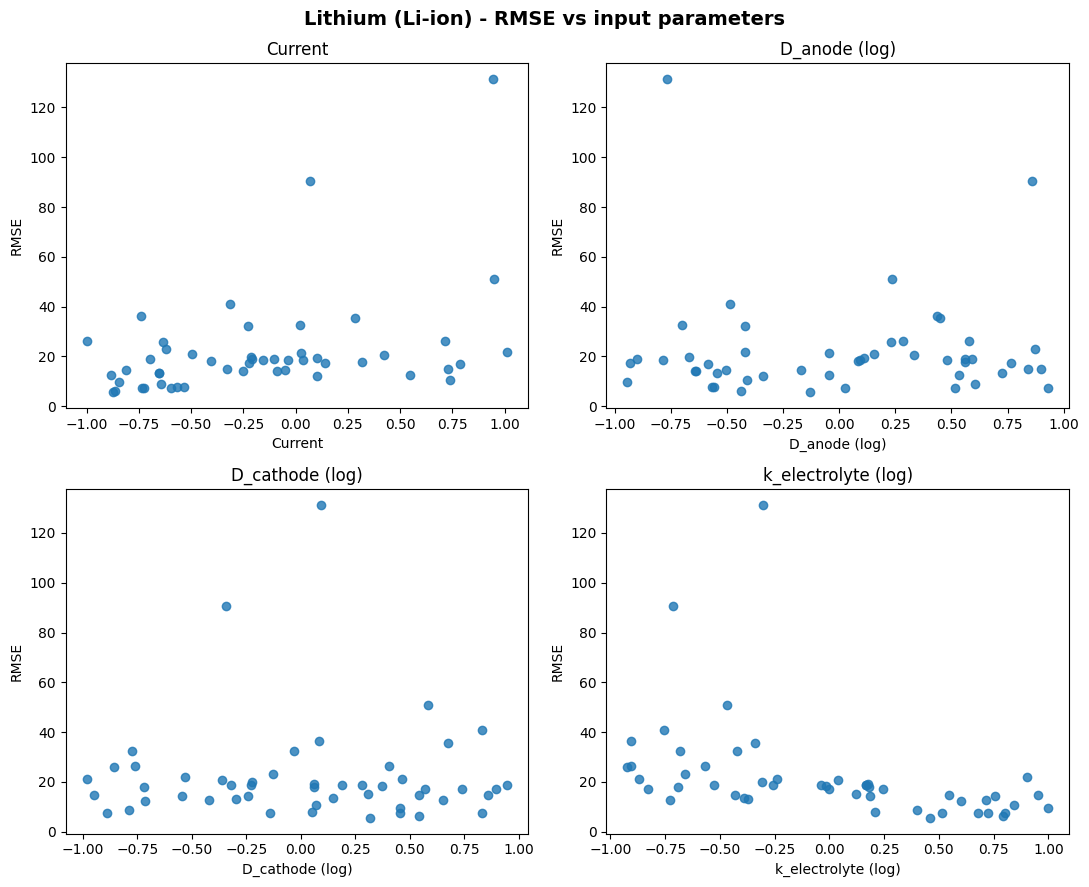

Lithium (Li-ion) - Spearman correlations between RMSE and inputs
Current: Spearman correlation = 0.381 (p=0.006)
D_anode (log): Spearman correlation = 0.075 (p=0.607)
D_cathode (log): Spearman correlation = -0.048 (p=0.742)
k_electrolyte (log): Spearman correlation = -0.677 (p=0.000)

Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])


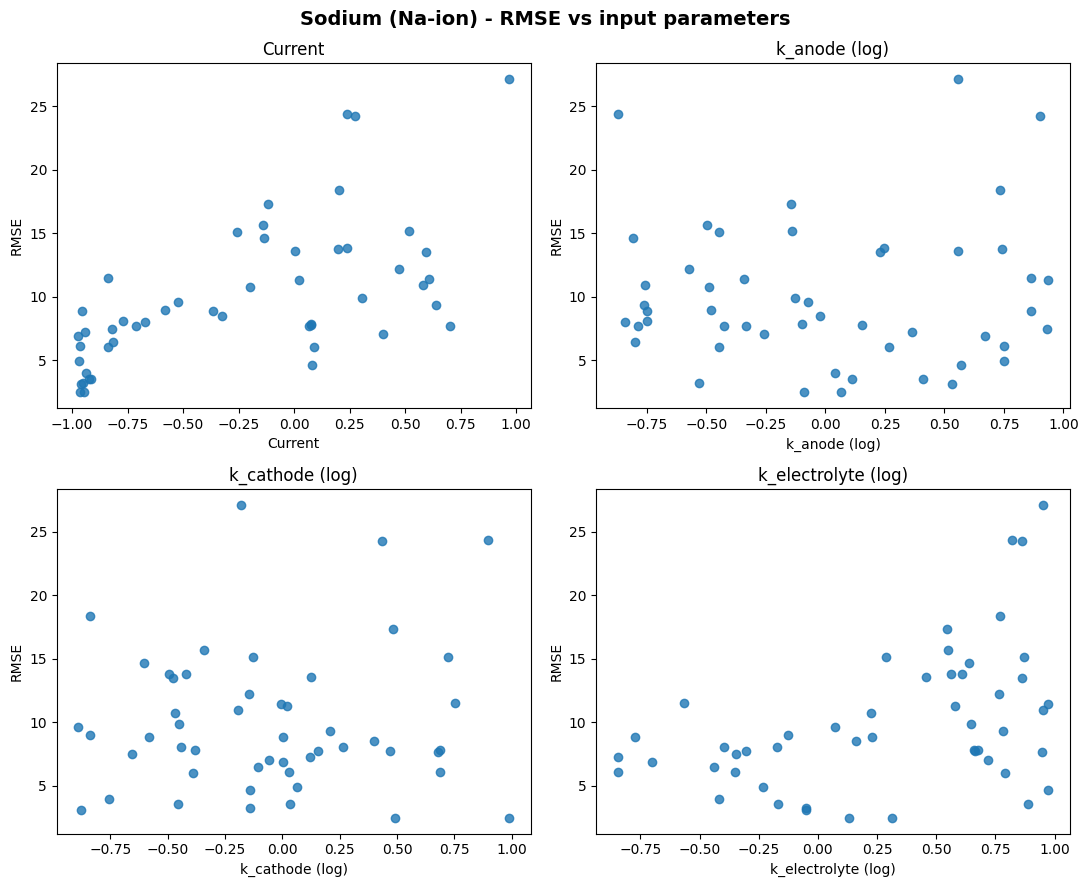

Sodium (Na-ion) - Spearman correlations between RMSE and inputs
Current: Spearman correlation = 0.635 (p=0.000)
k_anode (log): Spearman correlation = -0.088 (p=0.545)
k_cathode (log): Spearman correlation = -0.056 (p=0.698)
k_electrolyte (log): Spearman correlation = 0.395 (p=0.005)



In [11]:
from scipy.stats import spearmanr

for chemistry_key, cfg in CHEMISTRIES.items():
    print("=" * 60)
    param_names = PARAM_LABELS[chemistry_key]
    test_dataset = get_test_split(BatteryDataset(cfg["dataset_file"]), cfg["dataset_file"])

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    fig.suptitle(f"{cfg['label']} - RMSE vs input parameters", fontsize=14, fontweight="bold")
    for j, ax in enumerate(axes.flat):
        values = [test_dataset[i][0][j].item() for i in range(len(test_dataset))]
        ax.scatter(values, eval_results[chemistry_key]["rmse"], alpha=0.8)
        ax.set_xlabel(param_names[j])
        ax.set_ylabel("RMSE")
        ax.set_title(param_names[j])
    plt.tight_layout()
    plt.show()

    print(f"{cfg['label']} - Spearman correlations between RMSE and inputs")
    for j, name in enumerate(param_names):
        values = [test_dataset[i][0][j].item() for i in range(len(test_dataset))]
        corr, pval = spearmanr(values, eval_results[chemistry_key]["rmse"])
        print(f"{name}: Spearman correlation = {corr:.3f} (p={pval:.3f})")
    print()

## 6. Computational Speed Benchmark — PyBaMM vs. FNO

Compares the time of the full PyBaMM DFN solve against the FNO surrogate
(sequential and batched inference).

In [12]:
NUM_BENCHMARK_SAMPLES = 10  # good balance between speed and accuracy

def benchmark_chemistry(chemistry_key, num_samples=NUM_BENCHMARK_SAMPLES):
    cfg = CHEMISTRIES[chemistry_key]
    print("=" * 60)
    print("   SPEED BENCHMARK: PHYSICS ENGINE vs AI SURROGATE")
    print(f"   Chemistry: {cfg['label']}")
    print("=" * 60)

    full_dataset = BatteryDataset(cfg["dataset_file"])
    sf = full_dataset.scaling_factors
    start_idx = len(full_dataset) - num_samples

    test_inputs_norm, test_inputs_phys = [], []
    print(f"Extracting {num_samples} test samples...")
    for i in range(start_idx, len(full_dataset)):
        inputs_norm, _ = full_dataset[i]
        test_inputs_norm.append(inputs_norm)

        inp = inputs_norm.numpy()
        I = denormalize(inp[0], sf[0], sf[1])
        Da = 10 ** denormalize(inp[1], sf[2], sf[3])
        Dc = 10 ** denormalize(inp[2], sf[4], sf[5])
        De = 10 ** denormalize(inp[3], sf[6], sf[7])
        test_inputs_phys.append(dict(zip(INPUT_NAMES[chemistry_key], [I, Da, Dc, De])))

    print(f"\n[1/3] Initializing PyBaMM Physical Solver ({cfg['pybamm_parameter_set']})...")
    sim = build_pybamm_simulation(chemistry_key)

    print("      Running PyBaMM compiler warm-up...")
    sim.solve(t_eval=[0, 3600], inputs=test_inputs_phys[0])

    print("      Executing PyBaMM timing loop...")
    pybamm_times = []
    for phys in test_inputs_phys:
        start_t = time.perf_counter()
        try:
            sim.solve(t_eval=[0, 40000], inputs=phys)
        except pybamm.SolverError:
            pass
        pybamm_times.append(time.perf_counter() - start_t)
    avg_pybamm_time = np.mean(pybamm_times)
    print(f"      -> PyBaMM Average Time per Simulation: {avg_pybamm_time:.4f} seconds")

    print("\n[2/3] Initializing FNO Neural Surrogate...")
    model_fno = load_trained_model(cfg["model_path"])
    dummy_input = test_inputs_norm[0].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _ = model_fno(dummy_input)  # warm-up

    print("      Executing FNO sequential timing loop...")
    fno_seq_times = []
    with torch.no_grad():
        for inp in test_inputs_norm:
            inp = inp.unsqueeze(0).to(DEVICE)
            start_t = time.perf_counter()
            _ = model_fno(inp)
            fno_seq_times.append(time.perf_counter() - start_t)
    avg_fno_seq_time = np.mean(fno_seq_times)
    print(f"      -> FNO (Sequential) Average Time: {avg_fno_seq_time:.6f} seconds")

    print("      Executing FNO Batched timing (Parallel)...")
    batch_input = torch.stack(test_inputs_norm).to(DEVICE)
    with torch.no_grad():
        start_t = time.perf_counter()
        _ = model_fno(batch_input)
        end_t = time.perf_counter()
    avg_fno_batch_time = (end_t - start_t) / num_samples
    print(f"      -> FNO (Batched) Average Time per sim: {avg_fno_batch_time:.6f} seconds")

    speedup_seq = avg_pybamm_time / avg_fno_seq_time
    speedup_batch = avg_pybamm_time / avg_fno_batch_time

    print("\n" + "=" * 60)
    print(f"   FINAL BENCHMARK RESULTS: {cfg['label']}")
    print("=" * 60)
    print(f"PyBaMM DFN Solver    : {avg_pybamm_time:.4f} s")
    print(f"FNO Surrogate (Seq)  : {avg_fno_seq_time:.6f} s  --> {speedup_seq:,.1f}x FASTER")
    print(f"FNO Surrogate (Batch): {avg_fno_batch_time:.6f} s  --> {speedup_batch:,.1f}x FASTER")
    print("=" * 60 + "\n")

    fig, ax = plt.subplots(figsize=(9, 6))
    labels = ["PyBaMM\n(Physical Solver)", "FNO\n(Sequential)", "FNO\n(Batched)"]
    times = [avg_pybamm_time, avg_fno_seq_time, avg_fno_batch_time]
    colors = ["#d73027", "#4575b4", "#74add1"]

    bars = ax.bar(labels, times, color=colors, edgecolor="black", log=True)
    ax.set_ylabel("Execution Time per Simulation [Seconds] (Log Scale)", fontsize=12, fontweight="bold")
    ax.set_title(f"Computational Acceleration: PyBaMM vs FNO Surrogate\n{cfg['label']}",
                 fontsize=14, fontweight="bold", pad=20)
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)

    ax.text(bars[0].get_x() + bars[0].get_width() / 2, times[0] * 1.2, f"{times[0]:.2f} s",
            ha="center", va="bottom", fontweight="bold")
    ax.text(bars[1].get_x() + bars[1].get_width() / 2, times[1] * 1.2,
            f"{times[1] * 1000:.1f} ms\n({speedup_seq:,.0f}x)", ha="center", va="bottom",
            fontweight="bold", color="#1a4a75")
    ax.text(bars[2].get_x() + bars[2].get_width() / 2, times[2] * 1.2,
            f"{times[2] * 1000:.2f} ms\n({speedup_batch:,.0f}x)", ha="center", va="bottom",
            fontweight="bold", color="#1a4a75")

    fig.tight_layout()
    return {"pybamm": avg_pybamm_time, "fno_seq": avg_fno_seq_time, "fno_batch": avg_fno_batch_time}

   SPEED BENCHMARK: PHYSICS ENGINE vs AI SURROGATE
   Chemistry: Lithium (Li-ion)
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Extracting 10 test samples...

[1/3] Initializing PyBaMM Physical Solver (Chen2020)...
      Running PyBaMM compiler warm-up...
      Executing PyBaMM timing loop...


At t = 210.744, , mxstep steps taken before reaching tout.
At t = 210.744, , mxstep steps taken before reaching tout.
At t = 334.496, , mxstep steps taken before reaching tout.
At t = 97.494 and h = 2.13549e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 97.4935 and h = 1.96726e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 97.4945 and h = 9.93157e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 22.4938 and h = 5.25326e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 22.4937 and h = 1.21908e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 22.4926 and h = 2.03179e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 22.4941, , mxstep steps taken before reaching tout.
At t = 22.4938 and h = 1.83847e-11, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 3.74354 and h = 2.05053e-11, the corrector convergence fai

      -> PyBaMM Average Time per Simulation: 7.3860 seconds

[2/3] Initializing FNO Neural Surrogate...
      Executing FNO sequential timing loop...
      -> FNO (Sequential) Average Time: 0.020143 seconds
      Executing FNO Batched timing (Parallel)...
      -> FNO (Batched) Average Time per sim: 0.005942 seconds

   FINAL BENCHMARK RESULTS: Lithium (Li-ion)
PyBaMM DFN Solver    : 7.3860 s
FNO Surrogate (Seq)  : 0.020143 s  --> 366.7x FASTER
FNO Surrogate (Batch): 0.005942 s  --> 1,243.0x FASTER

   SPEED BENCHMARK: PHYSICS ENGINE vs AI SURROGATE
   Chemistry: Sodium (Na-ion)
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Extracting 10 test samples...

[1/3] Initializing PyBaMM Physical Solver (Chayambuka2022)...
      Running PyBaMM compiler warm-up...
      Executing PyBaMM timing loop...


At t = 91.0751, , mxstep steps taken before reaching tout.
At t = 91.0751, , mxstep steps taken before reaching tout.
At t = 91.0751, , mxstep steps taken before reaching tout.
At t = 107.461, , mxstep steps taken before reaching tout.
At t = 107.461, , mxstep steps taken before reaching tout.
At t = 107.461, , mxstep steps taken before reaching tout.
At t = 32.4605, , mxstep steps taken before reaching tout.
At t = 32.4605, , mxstep steps taken before reaching tout.
At t = 13.7105, , mxstep steps taken before reaching tout.
At t = 86.2911, , mxstep steps taken before reaching tout.
At t = 86.2911, , mxstep steps taken before reaching tout.
At t = 86.2911, , mxstep steps taken before reaching tout.
At t = 153.051, , mxstep steps taken before reaching tout.
At t = 153.051, , mxstep steps taken before reaching tout.
At t = 22.6255, , mxstep steps taken before reaching tout.
At t = 22.6255, , mxstep steps taken before reaching tout.
At t = 22.6255, , mxstep steps taken before reaching tou

      -> PyBaMM Average Time per Simulation: 42.0712 seconds

[2/3] Initializing FNO Neural Surrogate...
      Executing FNO sequential timing loop...
      -> FNO (Sequential) Average Time: 0.049228 seconds
      Executing FNO Batched timing (Parallel)...
      -> FNO (Batched) Average Time per sim: 0.018612 seconds

   FINAL BENCHMARK RESULTS: Sodium (Na-ion)
PyBaMM DFN Solver    : 42.0712 s
FNO Surrogate (Seq)  : 0.049228 s  --> 854.6x FASTER
FNO Surrogate (Batch): 0.018612 s  --> 2,260.5x FASTER



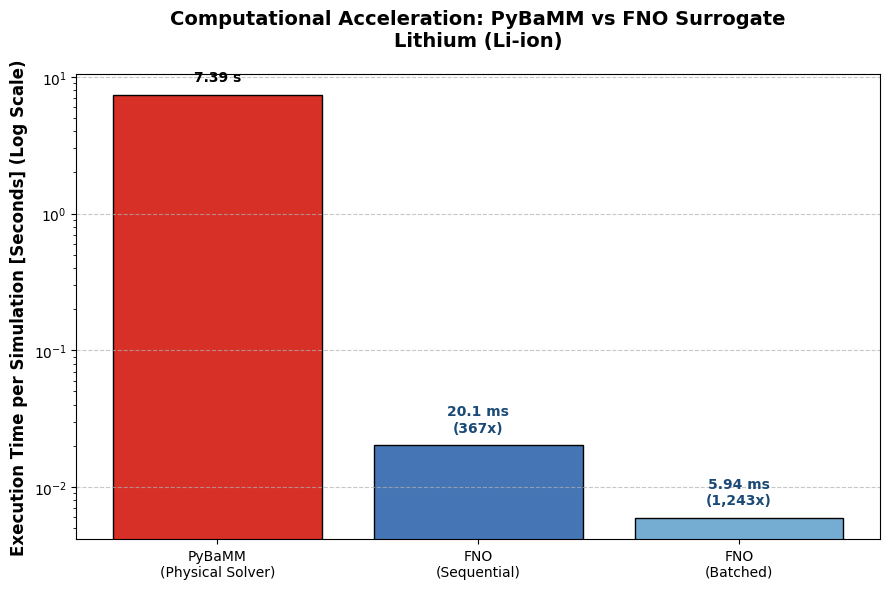

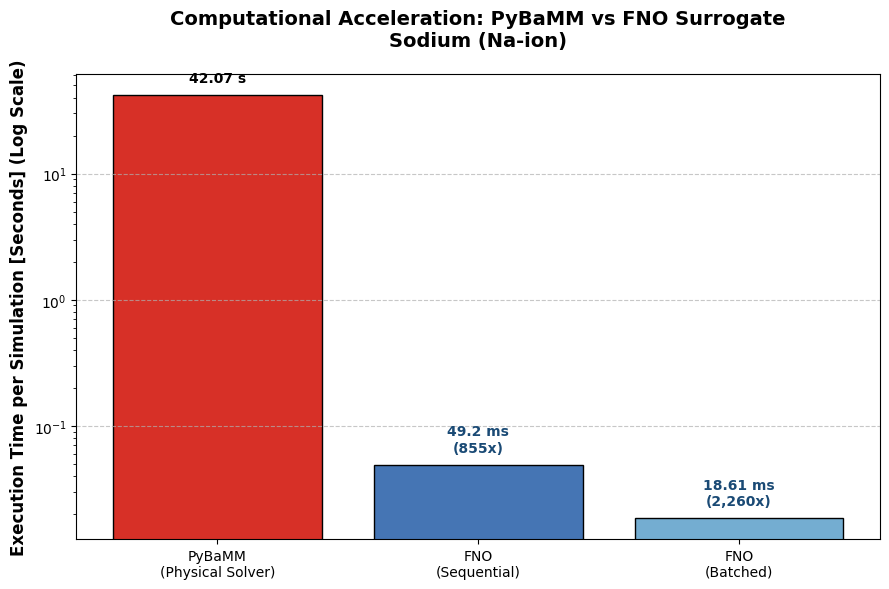

In [13]:
benchmark_results = {}
for chemistry_key in CHEMISTRIES:
    benchmark_results[chemistry_key] = benchmark_chemistry(chemistry_key)

plt.show()

## 7. Zero-Shot Super-Resolution

The Fourier layers are resolution-agnostic: a model trained on a 64x100 grid can be queried at an arbitrary grid size at inference time, with no retraining.

Because only a fixed number of low-frequency modes are kept (`modes1 = modes2 = 16`), querying at a much higher resolution can introduce mild *Gibbs-ringing* at sharp concentration gradients: this is a limitation of the truncated spectral representation, not just a rendering artifact.

Two checks are made:
- **Self-consistency**: the high-resolution forecast, downsampled to 64x100, must match the direct 64x100 forecast.
- **Validation against PyBaMM** (`validate_against_pybamm=True`, an independent simulation with a finer mesh): the only check that indicates whether the super-resolution is recovering real physical detail, rather than simply smoothing the interpolation.

In [14]:
def run_super_resolution(chemistry_key, size_x=256, size_y=400, sample_idx=None,
                          validate_against_pybamm=False,
                          validation_var_pts=None, validation_size_y=200,
                          make_plots=True):
    cfg = CHEMISTRIES[chemistry_key]
    print("=" * 60)
    print(f"   ZERO-SHOT SUPER RESOLUTION EXPERIMENT ({cfg['label'].upper()})")
    print("=" * 60)

    full_dataset = BatteryDataset(cfg["dataset_file"])
    sf = full_dataset.scaling_factors
    if sample_idx is None:
        sample_idx = len(full_dataset) - 5

    inputs_norm, _ = full_dataset[sample_idx]
    inputs_norm = inputs_norm.unsqueeze(0)

    model = load_trained_model(cfg["model_path"])

    print("Predicting Standard Resolution (64x100)...")
    with torch.no_grad():
        pred_standard = model(inputs_norm, size_x=64, size_y=100)

    print(f"Predicting Ultra-High Resolution ({size_x}x{size_y})...")
    with torch.no_grad():
        pred_highres = model(inputs_norm, size_x=size_x, size_y=size_y)

    Y_min, Y_max = sf[8], sf[9]
    pred_std_phys = denormalize(pred_standard.squeeze().numpy(), Y_min, Y_max)
    pred_hr_phys = denormalize(pred_highres.squeeze().numpy(), Y_min, Y_max)

    geom = get_geometry()

    if make_plots:
        # --- Figure 1: FNO standard vs. high resolution ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        vmin, vmax = np.min(pred_std_phys), np.max(pred_std_phys)
        im1 = axes[0].imshow(pred_std_phys, aspect="auto", origin="lower", cmap="viridis",
                              extent=[0, 100, 0, geom["L_total"]], vmin=vmin, vmax=vmax)
        axes[0].set_title("Standard Training Resolution\n(64 space x 100 time points)", fontweight="bold", fontsize=14)
        axes[0].set_ylabel(r"Physical Depth [$\mu m$]", fontsize=12, fontweight="bold")
        axes[0].set_xlabel("Normalized Time (% until cut-off)", fontsize=12)
        im2 = axes[1].imshow(pred_hr_phys, aspect="auto", origin="lower", cmap="viridis",
                              extent=[0, 100, 0, geom["L_total"]], vmin=vmin, vmax=vmax)
        axes[1].set_title(f"Zero-Shot Super Resolution\n({size_x} space x {size_y} time points)", fontweight="bold", fontsize=14)
        axes[1].set_xlabel("Normalized Time (% until cut-off)", fontsize=12)
        for ax, im in zip(axes, [im1, im2]):
            ax.axhline(y=geom["sep_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
            ax.axhline(y=geom["cat_start"], color="white", linestyle="--", linewidth=1.5, alpha=0.9)
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            fig.colorbar(im, cax=cax, label="Electrolyte Concentration [mol/m\u00b3]")
        plt.suptitle("FNO Resolution Invariance (Continuous Operator Learning)", fontsize=16, fontweight="bold", y=1.05)
        plt.tight_layout()
        plt.show()

    # --- Self-consistency check ---
    pred_hr_downsampled = F.interpolate(pred_highres, size=(64, 100), mode='bilinear', align_corners=False)
    diff = (pred_hr_downsampled - pred_standard).abs()
    self_consistency_max = diff.max().item()
    self_consistency_mean = diff.mean().item()
    print(f"\nSelf-consistency (normalized units [-1,1]) — max: {self_consistency_max:.4f}, mean: {self_consistency_mean:.4f}")

    result = {
        "chemistry_key": chemistry_key,
        "sample_idx": sample_idx,
        "self_consistency_max": self_consistency_max,
        "self_consistency_mean": self_consistency_mean,
        "rmse_val": None,
    }

    if not validate_against_pybamm:
        return result

    # --- PyBaMM validation, at a more moderate resolution decoupled from size_x/size_y ---
    if validation_var_pts is None:
        validation_var_pts = {"x_n": 43, "x_s": 40, "x_p": 43, "r_n": 10, "r_p": 10}  # 126 interni + 2 = 128
    val_size_x = validation_var_pts["x_n"] + validation_var_pts["x_s"] + validation_var_pts["x_p"] + 2

    print(f"\nSolving an independent PyBaMM simulation on a finer mesh "
          f"({val_size_x} spatial points) for validation...")

    I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, _, _ = sf
    inp = inputs_norm.squeeze().numpy()
    sample_inputs_phys = dict(zip(
        INPUT_NAMES[chemistry_key],
        [
            denormalize(inp[0], I_min, I_max),
            10 ** denormalize(inp[1], Da_min, Da_max),
            10 ** denormalize(inp[2], Dc_min, Dc_max),
            10 ** denormalize(inp[3], De_min, De_max),
        ]
    ))

    sim_fine = build_pybamm_simulation(chemistry_key, var_pts=validation_var_pts)
    try:
        sim_fine.solve(t_eval=[0, 40000], inputs=sample_inputs_phys)
    except pybamm.SolverError as e:
        print(f"  [!] Solver did not converge at this resolution for sample #{sample_idx}: {e}")
        print("      Try a different sample_idx or a coarser validation_var_pts.")
        return result

    t_max_fine = sim_fine.solution["Time [s]"].entries[-1]
    t_eval_fine = np.linspace(0, t_max_fine, validation_size_y)
    c_e_fine = sim_fine.solution["Electrolyte concentration [mol.m-3]"](t=t_eval_fine)

    with torch.no_grad():
        pred_val = model(inputs_norm, size_x=val_size_x, size_y=validation_size_y)
    pred_val_phys = denormalize(pred_val.squeeze().numpy(), Y_min, Y_max)

    error_map = np.abs(c_e_fine - pred_val_phys)
    rmse_val = np.sqrt(np.mean((c_e_fine - pred_val_phys) ** 2))
    result["rmse_val"] = rmse_val
    print(f"\nRMSE between FNO ({val_size_x}x{validation_size_y}) and PyBaMM (fine mesh): {rmse_val:.2f} mol/m\u00b3")

    if make_plots:
        fig2, axes2 = plt.subplots(1, 3, figsize=(22, 6))
        vmin2, vmax2 = min(c_e_fine.min(), pred_val_phys.min()), max(c_e_fine.max(), pred_val_phys.max())
        im1 = axes2[0].imshow(c_e_fine, aspect="auto", origin="lower", cmap="viridis",
                               extent=[0, 100, 0, geom["L_total"]], vmin=vmin2, vmax=vmax2)
        axes2[0].set_title("PyBaMM Ground Truth (Fine Mesh)", fontweight="bold", fontsize=13)
        axes2[0].set_ylabel(r"Physical Depth [$\mu m$]", fontsize=12, fontweight="bold")
        im2_ = axes2[1].imshow(pred_val_phys, aspect="auto", origin="lower", cmap="viridis",
                                extent=[0, 100, 0, geom["L_total"]], vmin=vmin2, vmax=vmax2)
        axes2[1].set_title("FNO (Same Resolution)", fontweight="bold", fontsize=13)
        im3 = axes2[2].imshow(error_map, aspect="auto", origin="lower", cmap="magma",
                               extent=[0, 100, 0, geom["L_total"]])
        axes2[2].set_title(f"Absolute Error (RMSE: {rmse_val:.1f} mol/m\u00b3)", fontweight="bold", fontsize=13)
        for ax in axes2:
            ax.axhline(y=geom["sep_start"], color="white", linestyle="--", linewidth=1.2, alpha=0.9)
            ax.axhline(y=geom["cat_start"], color="white", linestyle="--", linewidth=1.2, alpha=0.9)
            ax.set_xlabel("Normalized Time (% until cut-off)", fontsize=11)
        for ax, im, label in zip(axes2, [im1, im2_, im3],
                                  ["Concentration [mol/m\u00b3]", "Concentration [mol/m\u00b3]", "Error [mol/m\u00b3]"]):
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            fig2.colorbar(im, cax=cax, label=label)
        plt.suptitle(f"Super-Resolution Validation Against Independent Fine-Mesh Simulation — {cfg['label']}",
                     fontsize=15, fontweight="bold", y=1.03)
        plt.tight_layout()
        plt.show()

    return result


Sample Index: 1

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (LITHIUM (LI-ION))
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...


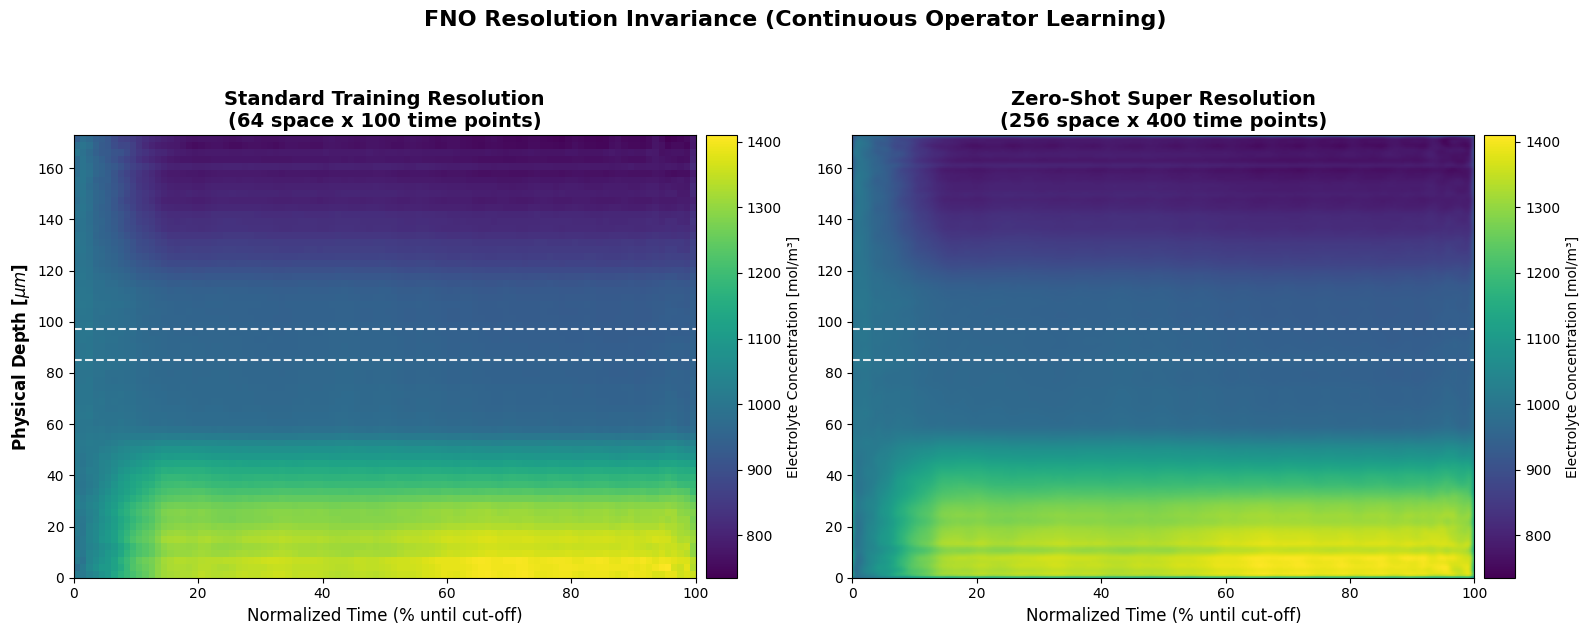


Self-consistency (normalized units [-1,1]) — max: 0.0188, mean: 0.0011

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 197.45, , mxstep steps taken before reaching tout.
At t = 197.45, , mxstep steps taken before reaching tout.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 17.98 mol/m³


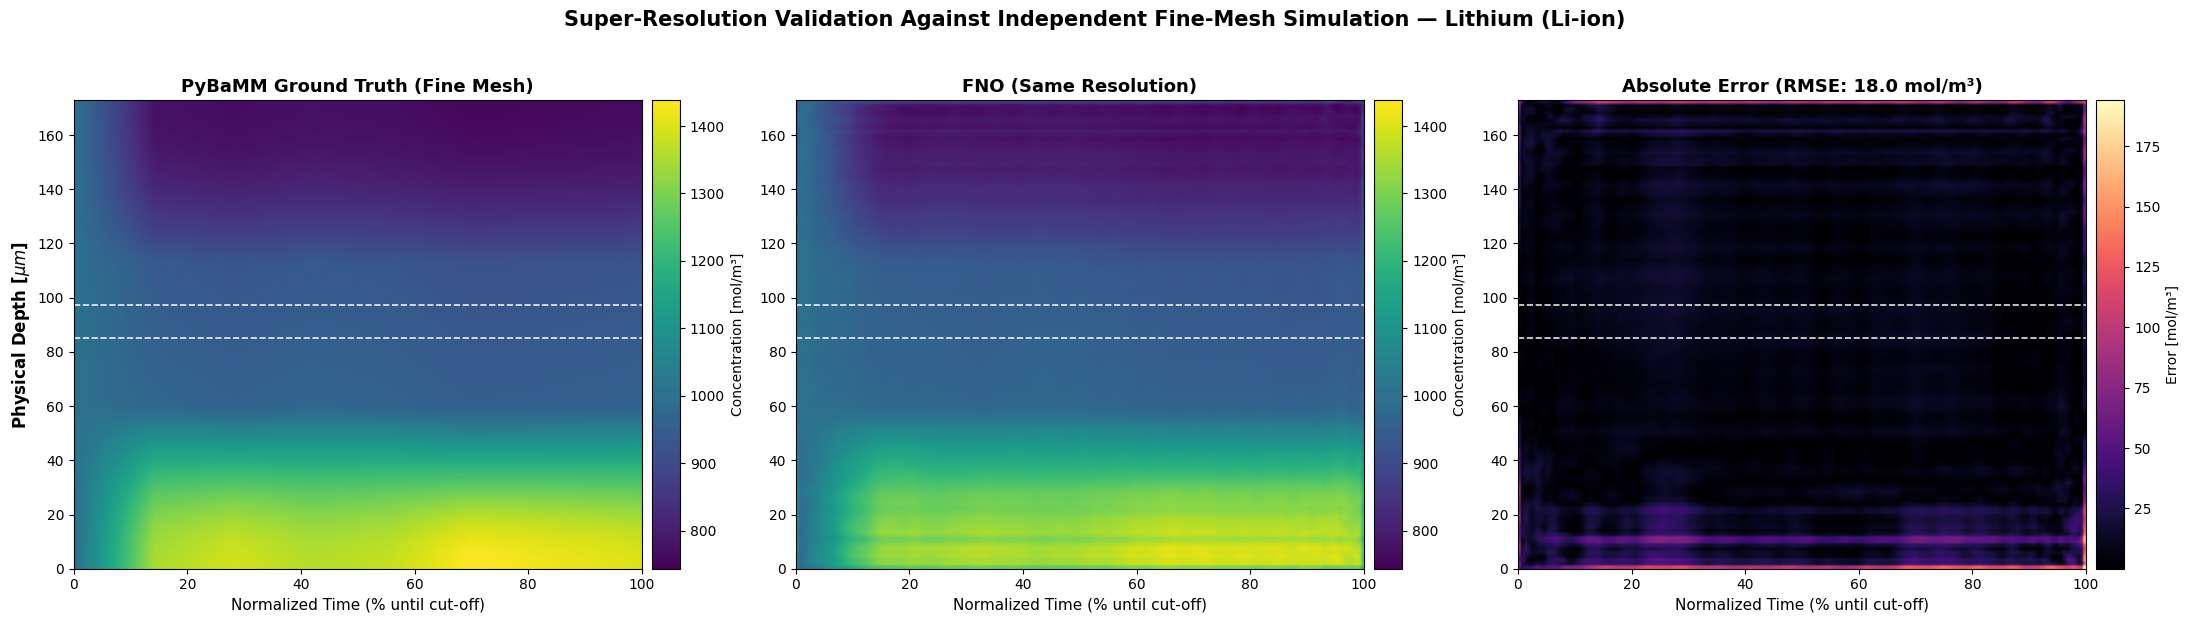


   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (SODIUM (NA-ION))
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...


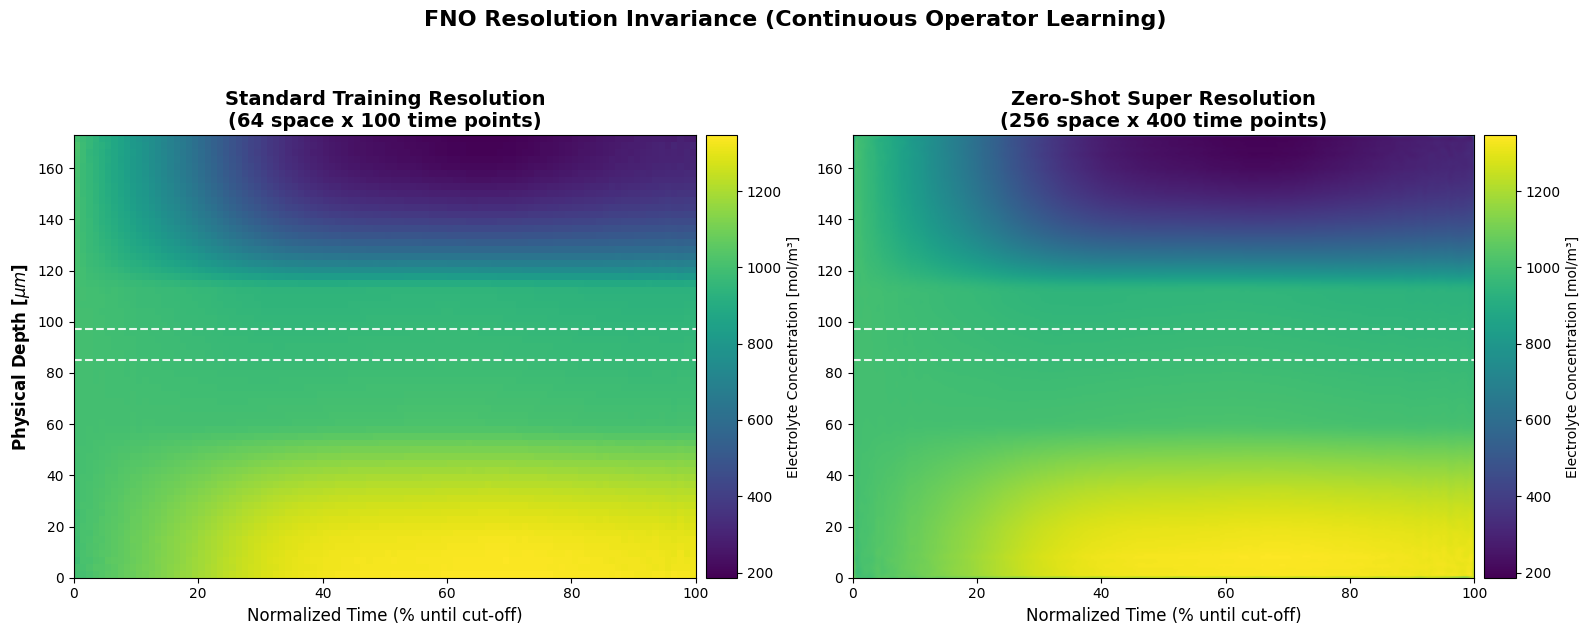


Self-consistency (normalized units [-1,1]) — max: 0.0247, mean: 0.0030

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 388.1, , mxstep steps taken before reaching tout.
At t = 88.1002, , mxstep steps taken before reaching tout.
At t = 88.1003, , mxstep steps taken before reaching tout.
At t = 13.1003, , mxstep steps taken before reaching tout.
At t = 13.1003, , mxstep steps taken before reaching tout.
At t = 13.1003, , mxstep steps taken before reaching tout.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 19.74 mol/m³


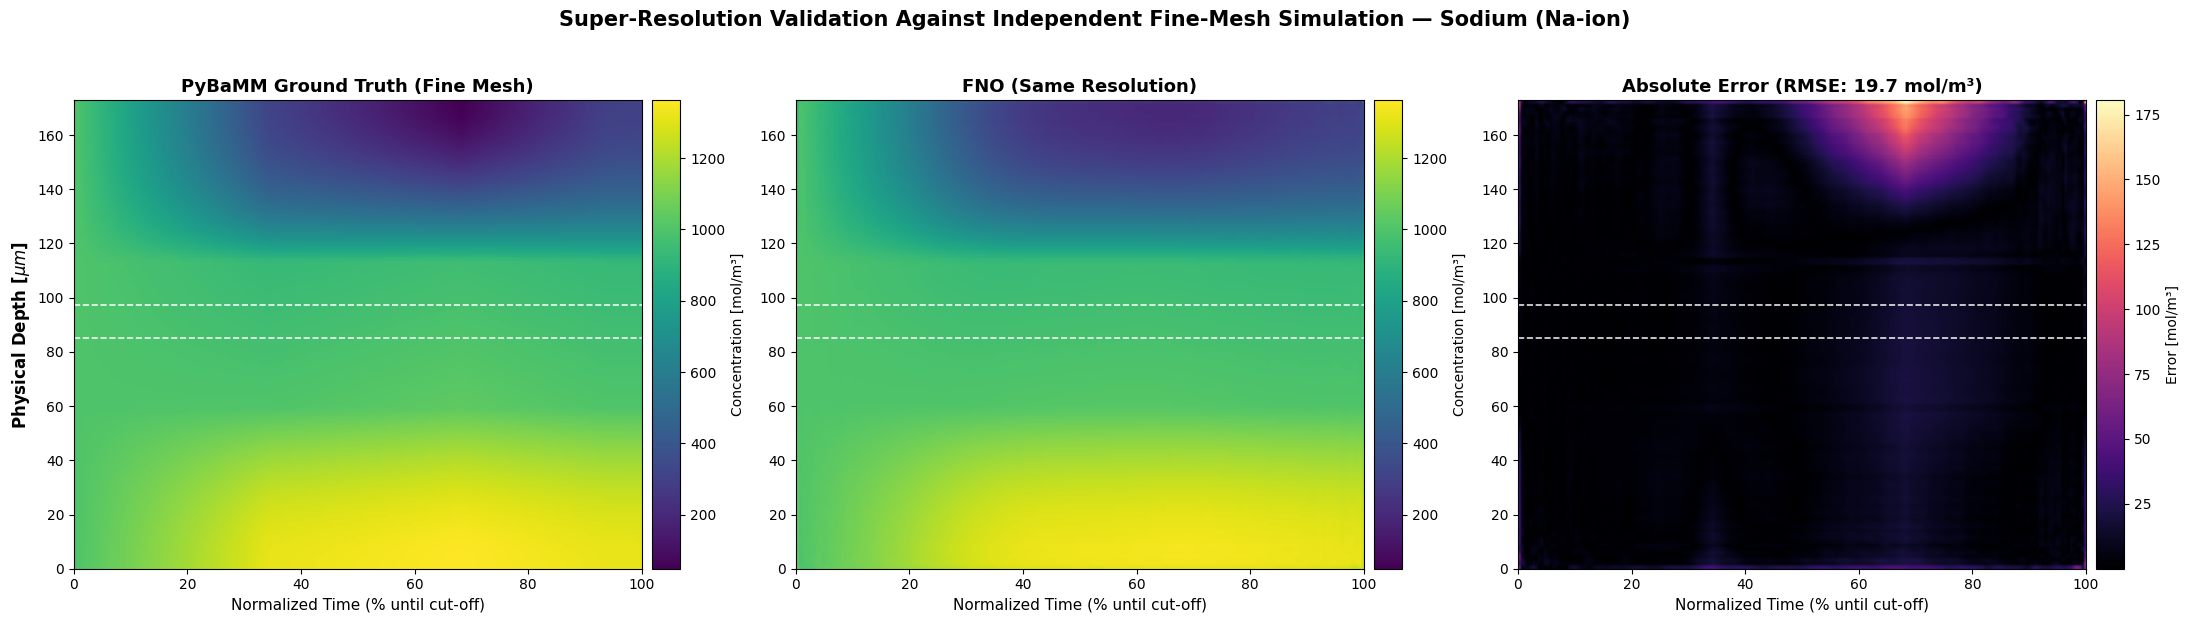


Sample Index: 11

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (LITHIUM (LI-ION))
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0216, mean: 0.0022

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...

RMSE between FNO (128x200) and PyBaMM (fine mesh): 15.29 mol/m³

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (SODIUM (NA-ION))
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0267, mean: 0.0027

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 33.7519, , mxstep steps taken before reaching tout.
At t = 33.7519, , mxstep steps taken before reaching tout.
At t = 33.7519, , mxstep steps taken before reaching tout.
At t = 33.7519, , mxstep steps taken before reaching tout.
At t = 33.7519, , mxstep steps taken before reaching tout.
At t = 15.0019, , mxstep steps taken before reaching tout.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 15.36 mol/m³

Sample Index: 22

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (LITHIUM (LI-ION))
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0231, mean: 0.0012

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 186.807, , mxstep steps taken before reaching tout.
At t = 186.807, , mxstep steps taken before reaching tout.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 19.79 mol/m³

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (SODIUM (NA-ION))
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0248, mean: 0.0028

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


...


RMSE between FNO (128x200) and PyBaMM (fine mesh): 9.64 mol/m³

Sample Index: 44

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (LITHIUM (LI-ION))
Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0368, mean: 0.0035

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 311.241 and h = 2.03791e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 11.2633 and h = 5.93966e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 11.2342 and h = 3.52866e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 11.206 and h = 3.95361e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 11.2244 and h = 2.5417e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 11.2614 and h = 1.00685e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 1.86691 and h = 4.12731e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 1.8861 and h = 2.84338e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 1.83897 and h = 5.90587e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.681008 and h = 1.91068e-09, the corrector convergence failed repeatedly or with |h| = hmin.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 36.04 mol/m³

   ZERO-SHOT SUPER RESOLUTION EXPERIMENT (SODIUM (NA-ION))
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Predicting Standard Resolution (64x100)...
Predicting Ultra-High Resolution (256x400)...

Self-consistency (normalized units [-1,1]) — max: 0.0260, mean: 0.0029

Solving an independent PyBaMM simulation on a finer mesh (128 spatial points) for validation...


At t = 217.982, , mxstep steps taken before reaching tout.
At t = 217.982, , mxstep steps taken before reaching tout.
At t = 67.9828, , mxstep steps taken before reaching tout.
At t = 67.9828, , mxstep steps taken before reaching tout.
At t = 30.4829, , mxstep steps taken before reaching tout.



RMSE between FNO (128x200) and PyBaMM (fine mesh): 10.58 mol/m³

   SUPER-RESOLUTION VALIDATION SUMMARY
Lithium (Li-ion): RMSE = 26.33 ± 12.17 mol/m³ (min 15.29, max 42.57, n=5)
Sodium (Na-ion): RMSE = 13.48 ± 4.12 mol/m³ (min 9.64, max 19.74, n=5)


In [15]:
sample_indices = [1, 11, 22, 33, 44]    # chosen randomly from the test set
results = []

for idx in sample_indices:
    show_plots = (idx == 1)
    print(f"\n{'='*60}\nSample Index: {idx}\n{'='*60}\n")
    results.append(run_super_resolution("lithium", sample_idx=idx, validate_against_pybamm=True, make_plots=show_plots))
    print("")
    results.append(run_super_resolution("sodium", sample_idx=idx, validate_against_pybamm=True, make_plots=show_plots))

print("\n" + "=" * 60)
print("   SUPER-RESOLUTION VALIDATION SUMMARY")
print("=" * 60)
for chem in ["lithium", "sodium"]:
    rmse_values = [r["rmse_val"] for r in results if r["chemistry_key"] == chem and r["rmse_val"] is not None]
    n_failed = sum(1 for r in results if r["chemistry_key"] == chem and r["rmse_val"] is None)
    label = CHEMISTRIES[chem]["label"]
    if rmse_values:
        print(f"{label}: RMSE = {np.mean(rmse_values):.2f} \u00b1 {np.std(rmse_values, ddof=1):.2f} mol/m\u00b3 "
              f"(min {np.min(rmse_values):.2f}, max {np.max(rmse_values):.2f}, n={len(rmse_values)}"
              + (f", {n_failed} failed" if n_failed else "") + ")")
    else:
        print(f"{label}: no successful validations")

## 6. Fair Comparison — Sodium vs Lithium (restricted current range)

The LHS sampling of sodium has a documented bias linked to the solver’s survival:
above approximately 2.5A, only samples with increasingly higher `k_electrolyte` values survive. Therefore, the sodium test set is not uniformly representative of its nominal range of 0.5–5A, unlike that of lithium.
Comparing the RMSE across the entire range (as in Section 5) risks measuring ‘how lenient the sampled space is for each chemistry’, rather than simply ‘how accurate each surrogate is’.

This section restricts the comparison to `Current <= a certain fair threshold`, the region where both chemistries have comparable coverage, and presents both the figures for the full range and the restricted range side by side.

In [7]:
def fair_comparison_stats(chemistry_key, current_threshold=FAIR_COMPARISON_CURRENT_THRESHOLD_A):
    """RMSE/MAE restricted to samples with Current <= current_threshold, so both chemistries
    are evaluated on a comparably-covered region of the input space."""
    cfg = CHEMISTRIES[chemistry_key]
    full_dataset = BatteryDataset(cfg["dataset_file"])
    sf = full_dataset.scaling_factors
    I_min, I_max = sf[0], sf[1]

    test_dataset = get_test_split(full_dataset, cfg["dataset_file"])
    currents_norm = np.array([test_dataset[i][0][0].item() for i in range(len(test_dataset))])
    currents_phys = denormalize(currents_norm, I_min, I_max)

    rmse = np.array(eval_results[chemistry_key]["rmse"])
    mae = np.array(eval_results[chemistry_key]["mae"])
    mask = currents_phys <= current_threshold

    return {
        "n_total": len(rmse), "n_fair": int(mask.sum()),
        "rmse_full": rmse, "mae_full": mae,
        "rmse_fair": rmse[mask], "mae_fair": mae[mask],
        "currents_phys": currents_phys,
    }


fair_data = {chem: fair_comparison_stats(chem) for chem in CHEMISTRIES}

print(f"Fair comparison threshold: Current <= {FAIR_COMPARISON_CURRENT_THRESHOLD_A} A")
print(f"Sodium extrapolation boundary (never trained beyond this): {NA_MAX_TRAINED_CURRENT_A} A\n")
print(f"{'Chemistry':<20}{'N (full)':>10}{'N (fair)':>10}{'RMSE full':>14}{'RMSE fair':>14}")
for chemistry_key, stats in fair_data.items():
    label = CHEMISTRIES[chemistry_key]["label"]
    rmse_fair_str = f"{np.mean(stats['rmse_fair']):.2f}" if stats["n_fair"] > 0 else "n/a"
    print(f"{label:<20}{stats['n_total']:>10}{stats['n_fair']:>10}"
          f"{np.mean(stats['rmse_full']):>14.2f}{rmse_fair_str:>14}")
    if stats["n_fair"] < 15:
        print(f"  [!] Only {stats['n_fair']} samples are below the threshold: the mean is unreliable, so it is recommended that this data be interpreted with caution.")

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Loading dataset from 'dataset_sodium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
Fair comparison threshold: Current <= 2.5 A
Sodium extrapolation boundary (never trained beyond this): 4.16 A

Chemistry             N (full)  N (fair)     RMSE full     RMSE fair
Lithium (Li-ion)            50         9         22.15         14.02
  [!] Only 9 samples are below the threshold: the mean is unreliable, so it is recommended that this data be interpreted with caution.
Sodium (Na-ion)             50        35          9.98          8.01


In [8]:
def stratified_rmse_table(current_bins=None):
    if current_bins is None:
        current_bins = np.arange(0.5, 5.5, 0.5)  # bande da 0.5A, da 0.5 a 5.0

    print(f"{'Current bin [A]':<18}{'N (Li)':>8}{'RMSE (Li)':>12}{'N (Na)':>8}{'RMSE (Na)':>12}")
    for lo, hi in zip(current_bins[:-1], current_bins[1:]):
        row = f"[{lo:.1f}, {hi:.1f})".ljust(18)
        for chem in ["lithium", "sodium"]:
            stats = fair_data[chem]
            mask = (stats["currents_phys"] >= lo) & (stats["currents_phys"] < hi)
            n = int(mask.sum())
            if n > 0:
                row += f"{n:>8}{np.mean(stats['rmse_full'][mask]):>12.2f}"
            else:
                row += f"{n:>8}{'--':>12}"
        print(row)

stratified_rmse_table()

Current bin [A]     N (Li)   RMSE (Li)  N (Na)   RMSE (Na)
[0.5, 1.0)               1       26.27      17        5.65
[1.0, 1.5)               2        9.15       4        8.59
[1.5, 2.0)               3       10.16       4       10.81
[2.0, 2.5)               3       17.04      10       10.65
[2.5, 3.0)               1       18.98       6       17.42
[3.0, 3.5)               6       15.35       6       11.71
[3.5, 4.0)               2        7.69       2        8.49
[4.0, 4.5)               1       21.08       1       27.16
[4.5, 5.0)               1       18.18       0          --


In [9]:
def bootstrap_mean_ci(values, n_boot=10000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    lo, hi = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return values.mean(), lo, hi


print("Bootstrap 95% CI on the mean RMSE in the 'fair' region (takes into account the low sample size, particularly for lithium):\n")
for chemistry_key, stats in fair_data.items():
    label = CHEMISTRIES[chemistry_key]["label"]
    if stats["n_fair"] >= 3:
        mean, lo, hi = bootstrap_mean_ci(stats["rmse_fair"])
        print(f"{label}: {mean:.2f} mol/m³  [95% CI: {lo:.2f}, {hi:.2f}]  (n={stats['n_fair']})")
    else:
        print(f"{label}: n={stats['n_fair']} too small for a meaningful bootstrap CI")

Bootstrap 95% CI on the mean RMSE in the 'fair' region (takes into account the low sample size, particularly for lithium):

Lithium (Li-ion): 14.02 mol/m³  [95% CI: 8.32, 21.05]  (n=9)
Sodium (Na-ion): 8.01 mol/m³  [95% CI: 6.76, 9.27]  (n=35)


In [10]:
from scipy.stats import mannwhitneyu

stat, pval = mannwhitneyu(
    fair_data["sodium"]["rmse_fair"],
    fair_data["lithium"]["rmse_fair"],
    alternative="less"  # H1: sodium RMSE is usually < lithium RMSE
)
print(f"Mann-Whitney U test (H1: sodium RMSE < lithium RMSE, fair region): p={pval:.3f}")

result = mannwhitneyu(fair_data["sodium"]["rmse_fair"], fair_data["lithium"]["rmse_fair"], alternative="less")
n1, n2 = len(fair_data["sodium"]["rmse_fair"]), len(fair_data["lithium"]["rmse_fair"])
prob_superiority = result.statistic / (n1 * n2)
print(f"P(sodium RMSE < lithium RMSE, randomly chosen couple) \u2248 {prob_superiority:.2f}")

stat_full, pval_full = mannwhitneyu(
    eval_results["sodium"]["rmse"],
    eval_results["lithium"]["rmse"],
    alternative="less"
)
print(f"Mann-Whitney U test, full range (n=50 vs n=50): p={pval_full:.4f}")

Mann-Whitney U test (H1: sodium RMSE < lithium RMSE, fair region): p=0.069
P(sodium RMSE < lithium RMSE, randomly chosen couple) ≈ 0.34
Mann-Whitney U test, full range (n=50 vs n=50): p=0.0000


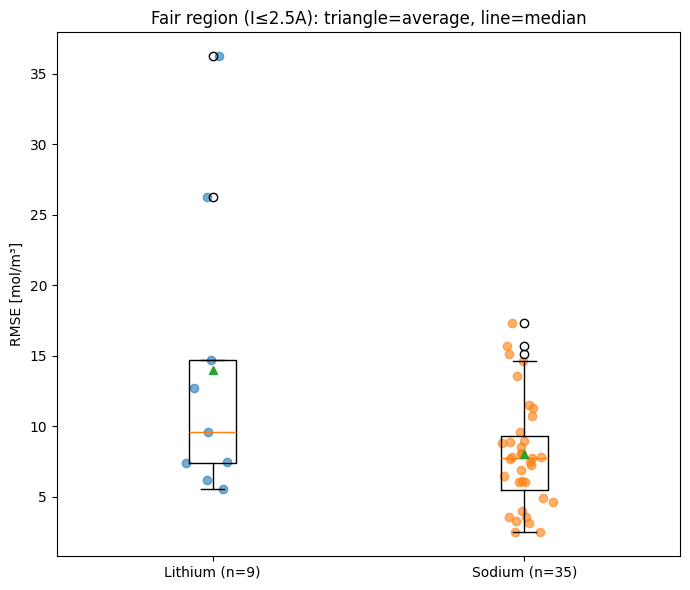

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
data_to_plot = [fair_data["lithium"]["rmse_fair"], fair_data["sodium"]["rmse_fair"]]
bp = ax.boxplot(data_to_plot, tick_labels=["Lithium (n=9)", "Sodium (n=35)"], showmeans=True)
for i, d in enumerate(data_to_plot, start=1):
    x = np.random.normal(i, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.6)
ax.set_ylabel("RMSE [mol/m³]")
ax.set_title("Fair region (I≤2.5A): triangle=average, line=median")
plt.tight_layout()
plt.show()

In [12]:
cfg = CHEMISTRIES["lithium"]
full_dataset = BatteryDataset(cfg["dataset_file"])
sf = full_dataset.scaling_factors
test_dataset = get_test_split(full_dataset, cfg["dataset_file"])

currents_phys = fair_data["lithium"]["currents_phys"]
rmse_full = fair_data["lithium"]["rmse_full"]
fair_mask = currents_phys <= FAIR_COMPARISON_CURRENT_THRESHOLD_A
fair_indices = np.where(fair_mask)[0]
fair_rmse = rmse_full[fair_mask]

I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, _, _ = sf
sorted_order = np.argsort(fair_rmse)[::-1]

print("The two worst samples in the fair region:")
for i in sorted_order[:2]:
    local_idx = fair_indices[i]
    inputs_norm, _ = test_dataset[local_idx]
    inp = inputs_norm.numpy()
    I_val = denormalize(inp[0], I_min, I_max)
    Da_val = 10 ** denormalize(inp[1], Da_min, Da_max)
    Dc_val = 10 ** denormalize(inp[2], Dc_min, Dc_max)
    ke_val = 10 ** denormalize(inp[3], De_min, De_max)
    print(f"  RMSE={fair_rmse[i]:.2f} | I={I_val:.2f}A | D_a={Da_val:.2e} | D_c={Dc_val:.2e} | k_e={ke_val:.2f}x")

print(f"Lithium  — fair region median: {np.median(fair_data['lithium']['rmse_fair']):.2f} mol/m³ (n=9)")
print(f"Sodium  — fair region median: {np.median(fair_data['sodium']['rmse_fair']):.2f} mol/m³ (n=35)")

Loading dataset from 'dataset_lithium_normalized.npz'...
Dataset loaded. X: torch.Size([500, 4]), Y: torch.Size([500, 1, 64, 100])
The two worst samples in the fair region:
  RMSE=36.26 | I=2.38A | D_a=2.74e-13 | D_c=1.21e-14 | k_e=0.33x
  RMSE=26.27 | I=0.53A | D_a=3.79e-13 | D_c=2.52e-14 | k_e=0.49x
Lithium  — fair region median: 9.61 mol/m³ (n=9)
Sodium  — fair region median: 7.74 mol/m³ (n=35)


# X. Testing area

In [16]:
# Controlla il valore di default (calibrato sulla letteratura da Chayambuka2022)
# PRIMA di sovrascriverlo con "[input]" -- usa un oggetto ParameterValues pulito
param_na_default = pybamm.ParameterValues("Chayambuka2022")
print("Default anode diffusivity:     ", param_na_default["Negative electrode diffusivity [m2.s-1]"])
print("Default cathode diffusivity:   ", param_na_default["Positive electrode diffusivity [m2.s-1]"])
print("Default electrolyte diffusivity:", param_na_default["Electrolyte diffusivity [m2.s-1]"])

param_li_default = pybamm.ParameterValues("Chen2020")
print("Default anode diffusivity (Li):     ", param_li_default["Negative electrode diffusivity [m2.s-1]"])
print("Default cathode diffusivity (Li):   ", param_li_default["Positive electrode diffusivity [m2.s-1]"])

Default anode diffusivity:      <function HC_diffusivity_Chayambuka2022 at 0x0000014DC1EBE3E0>
Default cathode diffusivity:    <function NVPF_diffusivity_Chayambuka2022 at 0x0000014DC1EBE660>
Default electrolyte diffusivity: <function electrolyte_diffusivity_Chayambuka2022 at 0x0000014DC1EBE7A0>
Default anode diffusivity (Li):      3.3e-14
Default cathode diffusivity (Li):    4e-15


In [17]:
sto_range = np.linspace(0.01, 0.99, 10)
T = 298.15

D_anode_func = param_na_default["Negative electrode diffusivity [m2.s-1]"]
D_cathode_func = param_na_default["Positive electrode diffusivity [m2.s-1]"]

# param_values.evaluate(expr) fa processing + evaluate in un solo passaggio:
# sostituisce ogni Parameter/FunctionParameter nell'espressione con il suo valore
# numerico vero, poi valuta il risultato.
D_anode_values = [float(param_na_default.evaluate(D_anode_func(s, T))) for s in sto_range]
D_cathode_values = [float(param_na_default.evaluate(D_cathode_func(s, T))) for s in sto_range]

print("D_anode(sto) range:  ", [f"{v:.2e}" for v in D_anode_values])
print("D_cathode(sto) range:", [f"{v:.2e}" for v in D_cathode_values])
print(f"\nD_anode:   min={min(D_anode_values):.2e}, max={max(D_anode_values):.2e}")
print(f"D_cathode: min={min(D_cathode_values):.2e}, max={max(D_cathode_values):.2e}")

D_anode(sto) range:   ['2.76e-16', '5.16e-16', '9.78e-16', '1.67e-15', '2.00e-15', '1.57e-15', '7.49e-16', '2.97e-16', '7.68e-16', '1.25e-15']
D_cathode(sto) range: ['2.72e-15', '2.53e-15', '2.34e-15', '2.15e-15', '1.96e-15', '1.78e-15', '1.62e-15', '1.49e-15', '1.36e-15', '1.23e-15']

D_anode:   min=2.76e-16, max=2.00e-15
D_cathode: min=1.23e-15, max=2.72e-15


In [18]:
for label, param_set in [("Chen2020 (Li)", param_li_default), ("Chayambuka2022 (Na)", param_na_default)]:
    D_e = param_set["Electrolyte diffusivity [m2.s-1]"]
    print(f"{label}: {D_e}")
    if callable(D_e):
        c_e_range = np.linspace(200, 2500, 8)  # mol/m3
        T = 298.15
        vals = [float(param_set.evaluate(D_e(c, T))) for c in c_e_range]
        print("  D_electrolyte(c_e) range:", [f"{v:.2e}" for v in vals])

Chen2020 (Li): <function electrolyte_diffusivity_Nyman2008 at 0x0000014DB9CA2160>
  D_electrolyte(c_e) range: ['4.10e-10', '3.01e-10', '2.10e-10', '1.39e-10', '8.64e-11', '5.29e-11', '3.84e-11', '4.28e-11']
Chayambuka2022 (Na): <function electrolyte_diffusivity_Chayambuka2022 at 0x0000014DC1EBE7A0>
  D_electrolyte(c_e) range: ['3.72e-11', '3.12e-11', '2.67e-11', '2.33e-11', '2.14e-11', '1.98e-11', '1.84e-11', '1.75e-11']
